In [1]:
## from sklearn.metrics import recall_score, make_scorer, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
# from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeClassifier as dtc
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import train_test_split,GridSearchCV
import numpy as np
import seaborn as sns    
import pandas as pd
import math
from matplotlib import cm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score # 导入accuracy_score函数
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, precision_score, f1_score,make_scorer, classification_report
from sklearn.model_selection import RepeatedKFold
from sklearn.feature_selection import SelectKBest
import sys
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import ListedColormap

df = pd.read_csv("class_2.csv")
# 第一次修改，43个0改1的修改，包括部分较远的0点
# df.loc[[587, 531, 9, 618, 586, 605, 566, 540, 570, 567, 594, 562, 513, 538, 434, 596, 220, 568, 28, 541, 617, 361, 519, 536, 512, 565, 564, 590, 516, 599, 560, 588, 32, 578, 593, 382, 192, 537, 615, 616, 184, 539, 470], 'class_2'] = 1
# 在第一次修改的43个点中去除了32，618， 220这三个较远的点,添加一个再pareto线上的点554,靠近pareto线的点 247，381,352,380
df.loc[[247,381,352,380,587, 531, 9, 28,519,470, 586, 605, 566, 540, 570, 567, 594, 562, 513,554, 538, 434, 596,568,  541, 617, 361,  536, 512, 565, 564, 590, 516, 599, 560, 588, 578, 593, 382, 192, 537, 615, 616, 184, 539], 'class_2'] = 1
# 再第二个基础上，加入第二轮错误的点进行修正，训练集0改1，592，607，569，620，619，#571，597, # 训练集中易混淆密集区的0改1  314, 364, 370, 396, 397, 540, 562, 600
# df.loc[[314, 364, 370, 396, 397, 540, 562, 600,592,607,569,620,619,247,381,352,380,587, 531, 9, 28,519,470, 586, 605, 566, 540, 570, 567, 594, 562, 513,554, 538, 434, 596,568,  541, 617, 361,  536, 512, 565, 564, 590, 516, 599, 560, 588, 578, 593, 382, 192, 537, 615, 616, 184, 539], 'class_2'] = 1

# 32 618这两个还是0点 ，添加大修后修依旧分错的点（也就是二次分错的点）
# df.loc[[587, 531, 9, 586, 605, 566, 540, 570, 567, 594, 562, 513, 538, 434, 596, 220, 568, 28, 541, 617, 361, 519, 536, 512, 565, 564, 590, 516, 599, 560, 588, 578, 593, 382, 192, 537, 615, 616, 184, 539, 470,515,332,554,592,607,569,620,619,597,571,287,68,343], 'class_2'] = 1 
# #有多个0点保持为0，添加修改后依旧分错的点
# df.loc[[587, 9, 220,28,568,331,287,608,343,361,551,519,605, 566, 540, 570, 567, 594, 513, 538, 434, 541, 617, 361, 536, 512, 565, 564, 590, 516, 599, 560, 588, 578, 593, 382, 192, 537, 615, 616, 184, 554,592,607,569,620,619,597,571,287,343], 'class_2'] = 1 
# 把分错的，较远的0点依旧保持0点
# df.loc[[587, 9, 605, 566, 570, 567, 594,513, 538, 434, 220, 28, 541, 617, 361, 519,  512, 565, 564, 590,516, 599, 560, 588,578, 593,382, 192, 537, 615, 616,184], 'class_2'] = 1
#7.3
# df.loc[[587, 9, 220,568,331,28,287,608,343,361,551,519,605, 566, 540, 570, 567, 594, 513, 538, 434, 541, 617, 361, 536, 512, 565, 564, 590, 516, 599, 560, 588, 578, 593, 382, 192, 537, 615, 616, 184, 554,592,607,569,620,619,597,571,287,68,343], 'class_2'] = 1 


X = df[['Ar', 'VE', 'EN', 'BP', 'Co']].to_numpy()
y = df.iloc[:, -1].to_numpy()
X=np.vstack((X[:,0]/100,X[:,1],X[:,2],X[:,3]/925,X[:,4])).T   # 对部分特征进行放缩  原子质量 价电子 电负性 沸点 内聚能

original_indices = np.arange(len(df)) 
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split( X, y, original_indices, test_size=0.2, random_state=15)

clf = dtc(max_depth=3,min_samples_split=8,max_features=3,min_impurity_decrease=0,random_state=15)
clf = clf.fit(X_train, y_train)

# # 网格搜索（优化 class_weight）
# scorer = make_scorer(f1_score, pos_label=1)
scorer = make_scorer(recall_score, pos_label=1)
# weights = [{0: 1, 1: w} for w in range(2, 6)]
# param_grid = {
#     # 'class_weight': weights,
#     'max_depth': [3, 4, 5, 6],
#     'min_samples_split': [8,9,10,11,12,15],
#     # 'min_samples_leaf':[5,6,7,8,9,10,15],
#     'max_features':[3,4]
# }

# clf1 = DecisionTreeClassifier(random_state=42)
# # clf1 = DecisionTreeClassifier(random_state=42,splitter="best")
# grid_search = GridSearchCV(
#     clf1,
#     param_grid=param_grid,
#     scoring=scorer,
#     cv=5,
#     verbose=1,
#     n_jobs=-1)
# grid_search.fit(X_train, y_train)
# best_clf = grid_search.best_estimator_
# print("最佳参数：", grid_search.best_params_)
# print("最佳 score：", grid_search.best_score_)

# clf = best_clf.fit(X_train, y_train)

In [2]:
leaf_ids = clf.apply(X_train)
# leaf_node = clf.apply(X_train) 
y_train_pred=clf.predict(X_train)
y_test_pred = clf.predict(X_test)

score_tr = clf.score(X_train,y_train)
score_te = clf.score(X_test,y_test)
score_tr,score_te
# print(np.unique(y_train,return_counts=True))
print("\n训练集评估报告：")
print(classification_report(y_train, y_train_pred, digits=4))
print("\测试集评估报告：")
print(classification_report(y_test, y_test_pred, digits=4))



训练集评估报告：
              precision    recall  f1-score   support

           0     0.9689    0.9639    0.9664       388
           1     0.8727    0.8889    0.8807       108

    accuracy                         0.9476       496
   macro avg     0.9208    0.9264    0.9236       496
weighted avg     0.9480    0.9476    0.9478       496

\测试集评估报告：
              precision    recall  f1-score   support

           0     0.9667    0.9560    0.9613        91
           1     0.8857    0.9118    0.8986        34

    accuracy                         0.9440       125
   macro avg     0.9262    0.9339    0.9299       125
weighted avg     0.9446    0.9440    0.9443       125



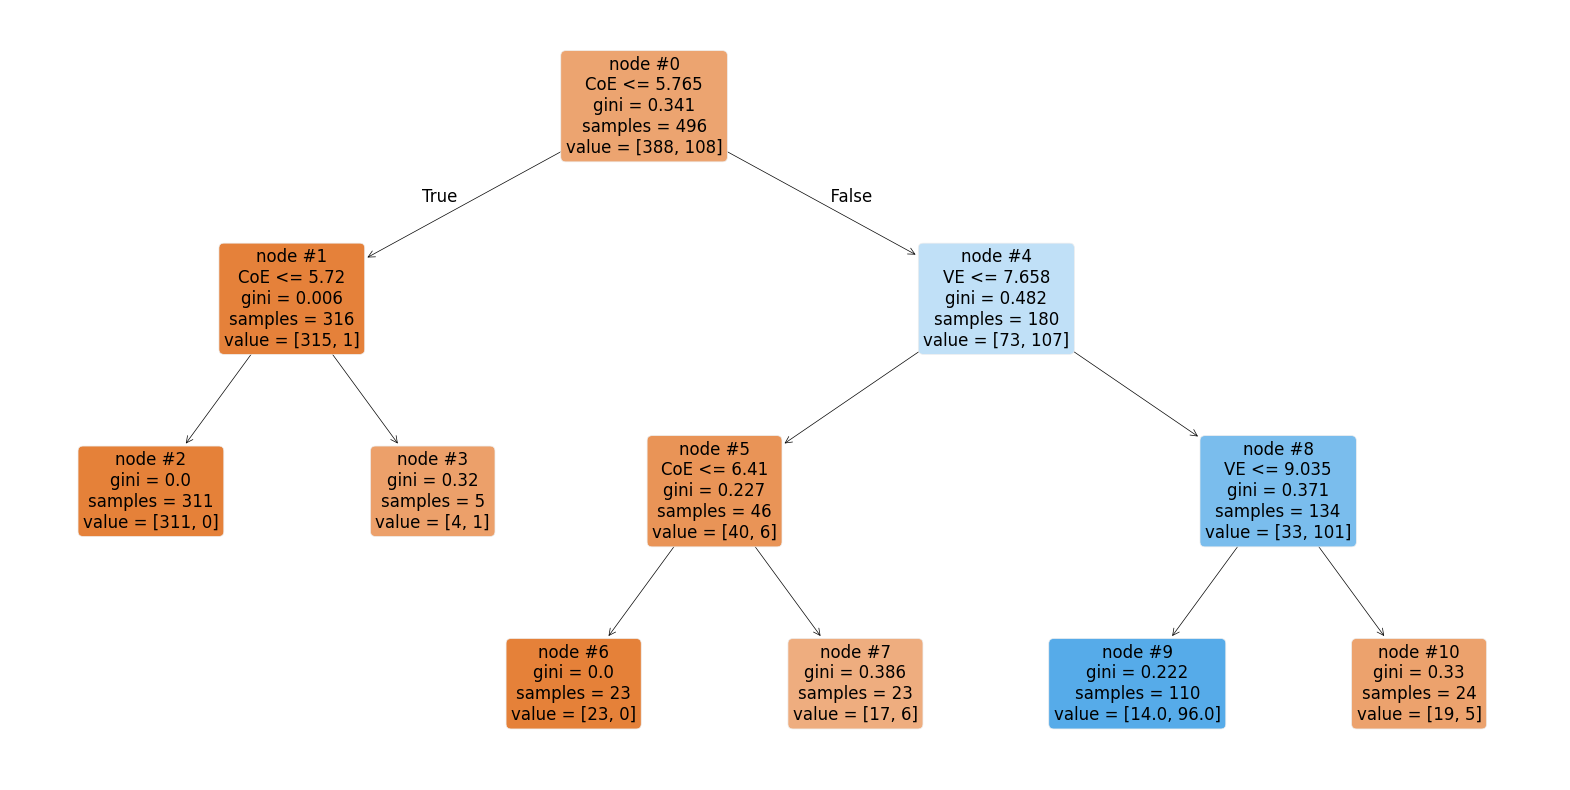

In [3]:
import matplotlib as mpl

plt.style.use('ggplot')
plt.figure(figsize=(20,10))      #设置画布大小（单位为英寸）
feature_names= ['Ar', 'VE', 'EN', 'BP', 'CoE']
cmap = plt.cm.viridis
# custom_cmap = ListedColormap(['#FF9999', '#66B2FF', '#99FF99', '#FFCC99'])
tree.plot_tree(clf , feature_names=feature_names,node_ids=True , filled=True , rounded=True,fontsize=12)   
plt.savefig("决策树-背景修改.png",transparent=True,dpi=300,bbox_inches='tight')      #保存图片一定要在plt.show()之前)   
plt.savefig("决策树-背景修改.svg",transparent=True,dpi=300,bbox_inches='tight')      #保存图片一定要在plt.show()之前
plt.show()

In [4]:
from collections import defaultdict


def analyze_tree_nodes_improved(clf, X_train, y_train, original_indices, new_indices):
    # 获取每个样本所在的叶子节点
    leaf_nodes = clf.apply(X_train)
    # 获取所有唯一的叶子节点ID
    unique_leaves = np.unique(leaf_nodes)
    # 分析每个叶子节点
    node_info = {}
    for leaf_id in unique_leaves:
        # 找到当前叶子节点的所有样本
        mask = leaf_nodes == leaf_id
        # 获取该叶子节点的样本索引
        leaf_indices = original_indices[mask]
        # 获取该叶子节点的实际标签
        leaf_labels = y_train[mask]
        # 获取预测标签
        leaf_predictions = clf.predict(X_train[mask])
        # 统计类别分布
        unique, counts = np.unique(leaf_labels, return_counts=True)
        class_distribution = dict(zip(unique, counts))    
        # 找出预测错误的样本
        misclassified_indices = leaf_indices[leaf_predictions != leaf_labels]
        misclassified_info = {
            'indices': misclassified_indices,
            'actual': leaf_labels[leaf_predictions != leaf_labels],
            'predicted': leaf_predictions[leaf_predictions != leaf_labels]
        } if len(misclassified_indices) > 0 else None
        
        # 存储节点信息
        node_info[leaf_id] = {
            'indices': leaf_indices,
            'actual_labels': leaf_labels,
            'predicted_labels': leaf_predictions,
            'class_distribution': class_distribution,
            'misclassified': misclassified_info
        }
    
    # 处理新索引
    new_indices_grouping = defaultdict(list)
    misclassified_new_samples = []
    
    if new_indices is not None and len(new_indices) > 0:
        # 找出新索引在原始数据中的位置
        mask = np.isin(original_indices, new_indices)
        if np.any(mask):
            new_leaf_nodes = clf.apply(X_train[mask])
            new_predictions = clf.predict(X_train[mask])
            new_actual = y_train[mask]
            new_original_indices = original_indices[mask]
            
            # 按叶子节点分组
            for idx, node_id, pred, actual in zip(new_original_indices, new_leaf_nodes, new_predictions, new_actual):
                new_indices_grouping[node_id].append({
                    'index': idx,
                    'predicted': pred,
                    'actual': actual
                })
                # 如果预测错误，添加到错误列表
                if pred != actual:
                    misclassified_new_samples.append({
                        'index': idx,
                        'node_id': node_id,
                        'predicted': pred,
                        'actual': actual
                    })
    
    return node_info, new_indices_grouping, misclassified_new_samples




under_pareto_indices=[56, 78, 106, 191, 219, 248, 277, 298, 311, 318, 319, 325, 330, 331, 340, 347, 348, 349, 354, 355, 359, 360, 369, 376, 377, 378, 383, 384, 388, 389, 414, 436, 442, 464, 465, 471, 472, 492, 493, 494, 500, 501, 526, 547, 555, 574, 583, 611, 612]
under_pareto_samples_leaves={}
print(len(under_pareto_indices))
# 获取分析结果
node_info, new_grouping, misclassified = analyze_tree_nodes_improved(
    clf, X_train, y_train, idx_train, under_pareto_indices)


# 打印新索引的分组情况
print("\n新索引在叶子节点中的分布:")
for node_id, samples in new_grouping.items():
    print(f"\n叶子节点 {node_id}:")
    print(f"包含的索引: {[s['index'] for s in samples]}")
    print(f"包含的索引个数: {len([s['index'] for s in samples])}")
    print(f"节点中的类别分布: {node_info[node_id]['class_distribution']}")

# 打印预测错误的新样本
if misclassified:
    print("\n预测错误的新样本:")
    for sample in misclassified:
        print(f"索引 {sample['index']} (在节点 {sample['node_id']}):")
        print(f"实际类别: {sample['actual']}, 预测类别: {sample['predicted']}")




49

新索引在叶子节点中的分布:

叶子节点 9:
包含的索引: [np.int64(347), np.int64(191), np.int64(465), np.int64(555), np.int64(526), np.int64(330), np.int64(106), np.int64(378), np.int64(471), np.int64(494), np.int64(612), np.int64(354), np.int64(348), np.int64(414), np.int64(388), np.int64(56), np.int64(383), np.int64(298), np.int64(349), np.int64(377), np.int64(500), np.int64(248), np.int64(78), np.int64(501), np.int64(369), np.int64(376), np.int64(359), np.int64(464), np.int64(340), np.int64(611), np.int64(472), np.int64(574), np.int64(360), np.int64(355), np.int64(331), np.int64(318), np.int64(384)]
包含的索引个数: 37
节点中的类别分布: {np.int64(0): np.int64(14), np.int64(1): np.int64(96)}


In [5]:
# 假设你想查看叶子节点ID为5的节点信息
pd.set_option('display.max_rows', None)  # 显示所有行
pd.set_option('display.max_columns', None)  # 显示所有列
pd.set_option('display.width', None)  # 不限制显示宽度
pd.set_option('display.max_colwidth', None)  # 不限制列内容宽度


leaf_id = 9  # 替换为你想查看的叶子节点ID
print(f"叶子节点 {leaf_id} 的全部信息:")
main_info = {
    'index': node_info[leaf_id]['indices'],
    'actual': node_info[leaf_id]['actual_labels'],
    'predicted': node_info[leaf_id]['predicted_labels']
}
df_main = pd.DataFrame(main_info)
display(df_main)
df_main.to_excel('for_main.xlsx', index=False)


leaf_indices = node_info[leaf_id]['indices'] 
if all(idx in df.index for idx in leaf_indices):
    # 获取这些索引对应的所有行
    leaf_rows = df.loc[leaf_indices]
    # print(f"叶子节点 {leaf_id} 对应的原始数据行:")
    display(leaf_rows)
    leaf_rows.to_excel('for_leaf_rows.xlsx', index=True)




叶子节点 9 的全部信息:


,index,actual,predicted
0,542,1,1
1,347,1,1
2,25,1,1
3,560,1,1
4,564,1,1
5,594,1,1
6,618,0,1
7,191,1,1
8,11,1,1
9,591,1,1


,name,Ar,VE,AR,EN,Ea,1st,BP,Co,Re,class_2
542,Ir2Co,443.367194,9.000000,176.278188,2.157465,139.395921,864.102545,4501.484282,6.45,3.79,1
347,Ru3Co,362.143194,8.162735,173.768903,2.147925,95.181183,718.369272,4223.975698,6.24,3.47,1
25,IrRu,293.287000,8.655389,179.310778,2.200000,133.872821,821.485010,4605.198072,8.40,5.10,1
560,Ir2Sc,429.390000,8.371816,180.418789,2.112054,137.085721,854.150222,4533.693617,6.72,3.81,1
564,Ir3Be,585.663183,8.892284,178.953616,2.190306,148.676412,880.300066,4670.870303,6.74,3.85,1
594,Ir4Mg,793.173000,8.785501,178.927504,2.172728,146.372945,875.639537,4598.714509,6.68,3.83,1
618,Ir4Te,896.468000,8.572991,171.886827,2.185766,156.579586,878.477001,4211.362891,6.12,4.20,0
191,CoOs,249.163194,8.236524,177.194692,2.124312,96.071362,821.172652,4791.846467,7.06,3.56,1
11,Rh,102.905490,9.000000,173.000000,2.280000,109.700000,719.700000,3968.000000,5.78,3.23,1
591,Ir3Ti,624.518000,8.616768,179.693415,2.149413,140.008919,863.045836,4613.546561,6.76,3.77,1


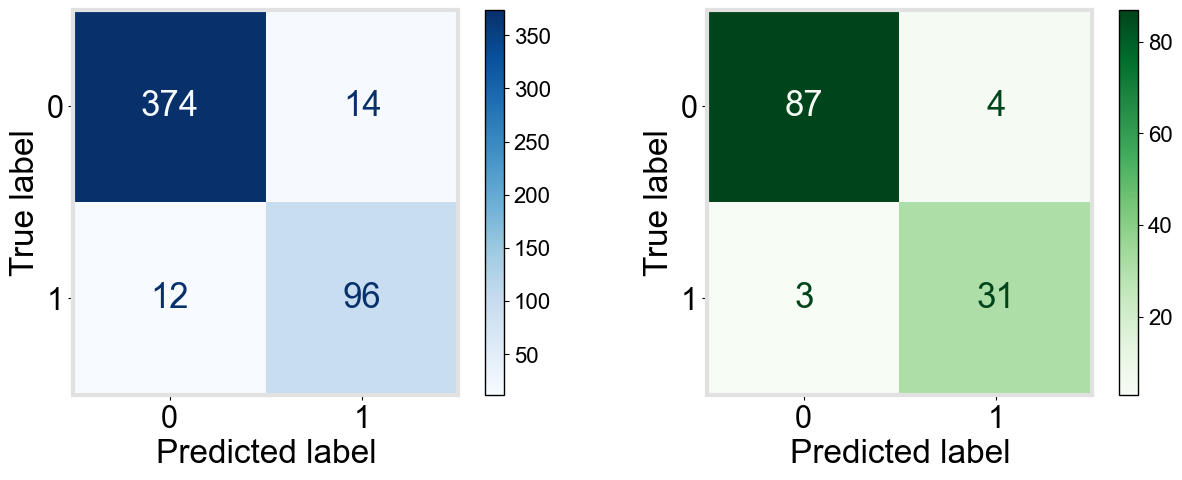

In [19]:
# 混淆矩阵用来可视化模型分类情况
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plt.rcParams['font.family'] = ['Arial']
plt.rcParams['font.size'] = 25 

cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=clf.classes_)
disp.plot(ax=axes[0],cmap='Blues', values_format='d')
# axes[0].set_title("Train Set Confusion Matrix")
axes[0].grid(False)
axes[0].set_xlabel('Predicted label', color='black', fontsize=24)
axes[0].set_ylabel('True label', color='black', fontsize=24)
axes[0].tick_params(axis='both', which='major', labelcolor='black',labelsize=22)
# for text in disp.text_.ravel():
#     text.set_fontsize(20)
for spine in axes[0].spines.values():
    spine.set_color('#E1E1E1')
    spine.set_linewidth(3)

cbar = disp.im_.colorbar
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1) 
cbar.ax.tick_params(labelsize=16,labelcolor='black')

cm1 = confusion_matrix(y_test, y_test_pred)
disp1 = ConfusionMatrixDisplay(cm1, display_labels=clf.classes_)
disp1.plot(ax=axes[1],cmap='Greens', values_format='d')
# axes[1].set_title('Test Set Confusion Matrix')
axes[1].grid(False)
axes[1].set_xlabel('Predicted label', color='black', fontsize=24)
axes[1].set_ylabel('True label', color='black', fontsize=24)
axes[1].tick_params(axis='both', which='major', labelcolor='black',labelsize=22)
# for text in disp1.text_.ravel():
#     text.set_fontsize(18)

for spine in axes[1].spines.values():
    spine.set_color('#E1E1E1')
    spine.set_linewidth(3)

cbar1 = disp1.im_.colorbar
cbar1.outline.set_edgecolor('black')
cbar1.outline.set_linewidth(1)
cbar1.ax.tick_params(labelsize=16,labelcolor='black')
plt.savefig('Training Set Confusion Matrix-4.13.png',bbox_inches='tight')
plt.show()




In [7]:
# 构造只包含训练集部分的特征 DataFrame
X_train_df = pd.DataFrame(X_train, columns=['Ar', 'VE', 'EN', 'BP', 'Co'])
# 添加预测结果
results_df = X_train_df.copy()
results_df = pd.DataFrame({
    'True_Label': y_train,
    'Pred_Label': y_train_pred,
    'Original_Index':idx_train
})
results_df['Is_Correct'] = results_df['True_Label'] == results_df['Pred_Label']

pd.options.display.width=80

# 找出错误预测的样本
error_samples = results_df[~results_df['Is_Correct']]
error_samples = error_samples.set_index('Original_Index')
error_indices = error_samples.index.tolist()
error_detail = df.loc[error_samples.index].copy()
error_detail['Pred_Label'] = error_samples['Pred_Label'].values
# print(error_indices)
print("训练集中错误分类的点：")
# display(error_detail)
# 找出错误分类中真实分类为0的索引
train_0_1_indices = error_samples[error_samples['True_Label'] == 0].index.tolist()
train_1_0_indices = error_samples[error_samples['True_Label'] == 1].index.tolist()
print("train_0_1_indices\n",train_0_1_indices)
print("train_1_0_indices\n",train_1_0_indices)


# 构造只包含训练集部分的特征 DataFrame
X_test_df = pd.DataFrame(X_test, columns=['Ar', 'VE', 'EN', 'BP', 'Co'])
# 添加预测结果
results_df1 = X_test_df.copy()
results_df1 = pd.DataFrame({
    'True_Label': y_test,
    'Pred_Label': y_test_pred,
    'Original_Index':idx_test
})
results_df1['Is_Correct'] = results_df1['True_Label'] == results_df1['Pred_Label']

pd.options.display.width=80

# 找出错误预测的样本
error_samples1 = results_df1[~results_df1['Is_Correct']]
error_samples1 = error_samples1.set_index('Original_Index')
error_indices1 = error_samples1.index.tolist()
error_detail1 = df.loc[error_samples1.index].copy()
error_detail1['Pred_Label'] = error_samples1['Pred_Label'].values
# print(error_indices1)
print("测试集中错误分类的点：")
# display(error_detail1)
test_0_1_indices = error_samples1[error_samples1['True_Label'] == 0].index.tolist()
test_1_0_indices = error_samples1[error_samples1['True_Label'] == 1].index.tolist()
print("test_0_1_indices\n",test_0_1_indices)
print("test_1_0_indices\n",test_1_0_indices)


训练集中错误分类的点：
train_0_1_indices
 [618, 515, 592, 511, 607, 220, 569, 589, 571, 558, 620, 619, 332, 597]
train_1_0_indices
 [35, 522, 79, 287, 608, 352, 7, 343, 551, 379, 381, 17]
测试集中错误分类的点：
test_0_1_indices
 [595, 499, 535, 598]
test_1_0_indices
 [579, 247, 380]


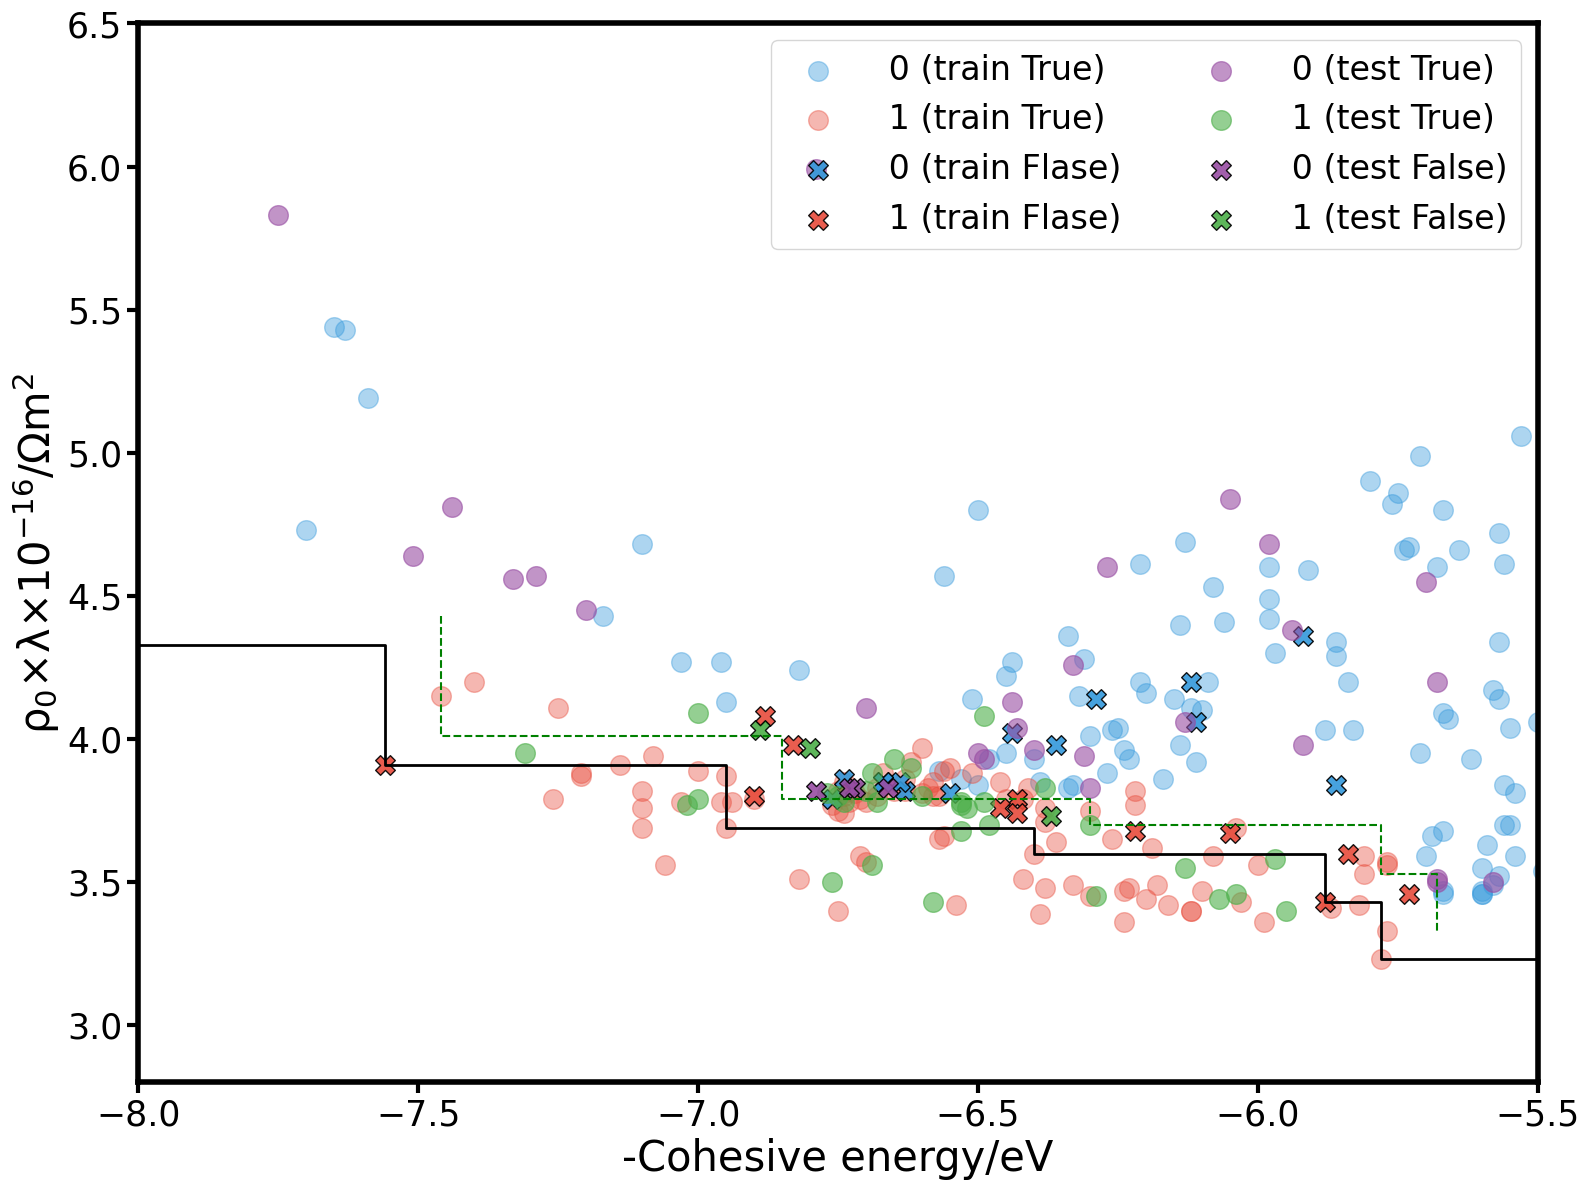

In [9]:

# # 1. 读取原始数据并添加索引列
# df = pd.read_csv("class_2.csv")
# # df.loc[[587, 531, 9, 618, 586, 605, 566, 540, 570, 567, 594, 562, 513, 538, 434, 596, 220, 568, 28, 541, 617, 361, 519, 536, 512, 565, 564, 590, 516, 599, 560, 588, 32, 578, 593, 382, 192, 537, 615, 616, 184, 539, 470], 'class_2'] = 1
# # df.loc[[587, 531, 9, 618, 586, 605, 566, 540, 570, 567, 594, 562, 513, 538, 434, 596, 220, 568, 28, 541, 617, 361, 519, 536, 512, 565, 564, 590, 516, 599, 560, 588, 578, 593, 382, 192, 537, 615, 616, 184, 539, 470], 'class_2'] = 1

# #shanchu 32 618这两个还是0点 ，2论修改
# # df.loc[[587, 531, 9, 586, 605, 566, 540, 570, 567, 594, 562, 513, 538, 434, 596, 220, 568, 28, 541, 617, 361, 519, 536, 512, 565, 564, 590, 516, 599, 560, 588, 578, 593, 382, 192, 537, 615, 616, 184, 539, 470,515,332,554,592,607,569,620,619,597,571,287,68,343], 'class_2'] = 1 
# # 7.3测试
# # df.loc[[587, 9, 220,568,331,28,287,608,343,361,551,519,605, 566, 540, 570, 567, 594, 513, 538, 434, 541, 617, 361, 536, 512, 565, 564, 590, 516, 599, 560, 588, 578, 593, 382, 192, 537, 615, 616, 184, 554,592,607,569,620,619,597,571,287,68,343], 'class_2'] = 1 
# # df.loc[[587, 9, 605, 566, 570, 567, 594,513, 538, 434, 220, 28, 541, 617, 361, 519,  512, 565, 564, 590,516, 599, 560, 588,578, 593,382, 192, 537, 615, 616,184], 'class_2'] = 1

# df.loc[[587, 9, 220,28,568,331,287,608,343,361,551,519,605, 566, 540, 570, 567, 594, 513, 538, 434, 541, 617, 361, 536, 512, 565, 564, 590, 516, 599, 560, 588, 578, 593, 382, 192, 537, 615, 616, 184, 554,592,607,569,620,619,597,571,287,343], 'class_2'] = 1 
df['original_index'] = df.index  # 保存原始索引以便追踪
X_ = df.iloc[:,[8]]
y_ = df.iloc[:,[9]] 
# class_2=df.iloc[:,[-1]]
class_info=df.iloc[:,[-2]]

# 训练集中错误和非错误索引
error_indices = error_samples.index.tolist()
train_all_indices = set(idx_train)
non_error_indices = list(train_all_indices - set(error_indices))
x_non_error = X_.loc[non_error_indices]
y_non_error = y_.loc[non_error_indices]
# 测试集中
error_indices1 = error_samples1.index.tolist()
test_all_indices = set(idx_test)
non_error_indices1 = list(test_all_indices - set(error_indices1))
x_non_error1 = X_.loc[non_error_indices1]
y_non_error1 = y_.loc[non_error_indices1]

# 建立训练集分类索引信息
class_info_non_error = class_info.loc[non_error_indices]
class_info_error = class_info.loc[error_indices]
x_error=X_.loc[error_indices]
y_error=y_.loc[error_indices]
# 测试集
class_info_non_error1 = class_info.loc[non_error_indices1]
class_info_error1 = class_info.loc[error_indices1]
x_error1=X_.loc[error_indices1]
y_error1=y_.loc[error_indices1]
# 读取pareto数据文件
pareto = np.loadtxt('pareto', delimiter=',')

plt.style.use('default')  # 重置样式
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['figure.facecolor'] = 'none'

plt.figure(figsize=(16,12))
ax = plt.gca()  # 获取当前轴对象
# ax.set_xlim(-9.215, -0.9650000000000001)
# ax.set_ylim(2.8800000000000003, 9.92)
ax.set_xlim(-8.0, -5.5)
ax.set_ylim(2.8, 6.5)
ax.spines['bottom'].set_linewidth(4)
ax.spines['left'].set_linewidth(4)
ax.spines['top'].set_linewidth(4)
ax.spines['right'].set_linewidth(4)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tick_params(axis='both', which='major', width=3)
plt.tick_params(axis='both', length=8)

colors = ['#3498db', '#e74c3c']  # 蓝色和红色，分别代表类别0和类别1
cmap = ListedColormap(colors)
class_names = [' 0', ' 1']
# colors1 = ['#ffd92f','#66c2a5']  # 绿黄，分别代表类别0和类别1
colors1 = ['#984ea3','#4daf4a']  # 绿紫色
cmap1 = ListedColormap(colors1)
plt.style.use('default')  # 重置样式
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['figure.facecolor'] = 'none'

# 绘制训练集正确分类的点
for i, class_name in enumerate(class_names):
    mask = (class_info_non_error.iloc[:, 0] == i) if hasattr(class_info_non_error, 'iloc') else (class_info_non_error == i)
    if np.any(mask):
        plt.scatter(-x_non_error[mask], y_non_error[mask], 
                   color=colors[i], s=200, marker='o', alpha=0.4 ,
                  label=f'{class_name} (train True)')
# 绘制训练集错误分类的点
for i, class_name in enumerate(class_names):
    mask = (class_info_error.iloc[:, 0] == i) if hasattr(class_info_error, 'iloc') else (class_info_error == i)
    if np.any(mask):
        plt.scatter(-x_error.iloc[:, 0][mask], y_error[mask], 
                   color=colors[i], s=200, marker='X', edgecolors='k', alpha=0.9,
                   label=f'{class_name} (train Flase)')
# 绘制测试集正确分类的点
for i, class_name in enumerate(class_names):
    mask = (class_info_non_error1.iloc[:, 0] == i) if hasattr(class_info_non_error1, 'iloc') else (class_info_non_error1 == i)
    if np.any(mask):
        plt.scatter(-x_non_error1[mask], y_non_error1[mask], 
                   color=colors1[i], s=200, marker='o', alpha=0.6, 
                   label=f'{class_name} (test True)')

# 绘制测试集错误分类的点
for i, class_name in enumerate(class_names):
    mask = (class_info_error1.iloc[:, 0] == i) if hasattr(class_info_error1, 'iloc') else (class_info_error1 == i)
    if np.any(mask):
        plt.scatter(-x_error1.iloc[:, 0][mask], y_error1[mask], 
                   color=colors1[i], s=200, marker='X',edgecolors='k',alpha=0.9,
                   label=f'{class_name} (test False)')

# 添加图例（可能需要调整位置或分成多列）
plt.legend(loc='best', ncol=2,prop={'size':24})
plt.plot(pareto[:,0],pareto[:,1],c='k',linewidth=2,label='pareto')

shifted_y = pareto[5:15, 1] + 0.1
# 绘制y+0.1的新前沿
plt.plot(pareto[5:15, 0]+0.1, shifted_y, c='g', linestyle='--', linewidth=1.5, label='x+0.1')
# plt.axhline(y=3.88,color='k',linestyle='--')
plt.xlabel('-Cohesive energy/eV',fontsize=30)
plt.ylabel('ρ$_0$×λ×10$^{-16}$/Ωm$^2$',fontsize=30)
# plt.legend(['train_correct','train_error','test_correct','test_error'],loc=4,fontsize=25,frameon=False)

# for i, idx in enumerate(error_indices):
#     plt.annotate(str(idx), 
#                 xy=(-x_error.iloc[i, 0], y_error.iloc[i, 0]),
#                 xytext=(-x_error.iloc[i, 0], y_error.iloc[i, 0] + 0.15),
#                 fontsize=9,
#                 ha='center',
#                 va='bottom',
#                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7),  # 添加背景框
#                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2'))

# # 标注序号
# for i, idx in enumerate(error_indices1):
#     plt.annotate(str(idx), 
#                 xy=(-x_error1.iloc[i, 0], y_error1.iloc[i, 0]),
#                 xytext=(-x_error1.iloc[i, 0], y_error1.iloc[i, 0] + 0.15),
#                 fontsize=9,
#                 ha='center',
#                 va='bottom',
#                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7),  # 添加背景框
#                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2'))


plt.tight_layout()
# plt.savefig('error-26-1-6.tiff',dpi=300, bbox_inches='tight')

# plt.savefig('error-26-1-27-1.pdf',dpi=300, bbox_inches='tight')
# plt.savefig('error-26-1-27-2.pdf',dpi=300, bbox_inches='tight')
plt.savefig('error-26-1-27.pdf',dpi=300, bbox_inches='tight')
# plt.savefig('error-8.10-1.png', dpi=300, bbox_inches='tight')
# plt.show()


plt.show()

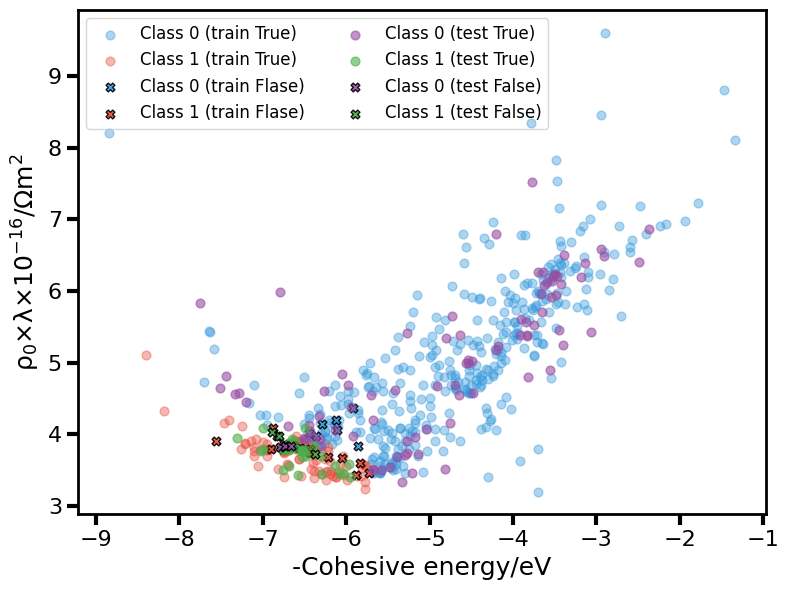

In [17]:

# # 1. 读取原始数据并添加索引列
# df = pd.read_csv("class_2.csv")
# # df.loc[[587, 531, 9, 618, 586, 605, 566, 540, 570, 567, 594, 562, 513, 538, 434, 596, 220, 568, 28, 541, 617, 361, 519, 536, 512, 565, 564, 590, 516, 599, 560, 588, 32, 578, 593, 382, 192, 537, 615, 616, 184, 539, 470], 'class_2'] = 1
# # df.loc[[587, 531, 9, 618, 586, 605, 566, 540, 570, 567, 594, 562, 513, 538, 434, 596, 220, 568, 28, 541, 617, 361, 519, 536, 512, 565, 564, 590, 516, 599, 560, 588, 578, 593, 382, 192, 537, 615, 616, 184, 539, 470], 'class_2'] = 1

# #shanchu 32 618这两个还是0点 ，2论修改
# # df.loc[[587, 531, 9, 586, 605, 566, 540, 570, 567, 594, 562, 513, 538, 434, 596, 220, 568, 28, 541, 617, 361, 519, 536, 512, 565, 564, 590, 516, 599, 560, 588, 578, 593, 382, 192, 537, 615, 616, 184, 539, 470,515,332,554,592,607,569,620,619,597,571,287,68,343], 'class_2'] = 1 
# # 7.3测试
# # df.loc[[587, 9, 220,568,331,28,287,608,343,361,551,519,605, 566, 540, 570, 567, 594, 513, 538, 434, 541, 617, 361, 536, 512, 565, 564, 590, 516, 599, 560, 588, 578, 593, 382, 192, 537, 615, 616, 184, 554,592,607,569,620,619,597,571,287,68,343], 'class_2'] = 1 
# # df.loc[[587, 9, 605, 566, 570, 567, 594,513, 538, 434, 220, 28, 541, 617, 361, 519,  512, 565, 564, 590,516, 599, 560, 588,578, 593,382, 192, 537, 615, 616,184], 'class_2'] = 1

# df.loc[[587, 9, 220,28,568,331,287,608,343,361,551,519,605, 566, 540, 570, 567, 594, 513, 538, 434, 541, 617, 361, 536, 512, 565, 564, 590, 516, 599, 560, 588, 578, 593, 382, 192, 537, 615, 616, 184, 554,592,607,569,620,619,597,571,287,343], 'class_2'] = 1 
df['original_index'] = df.index  # 保存原始索引以便追踪
X_ = df.iloc[:,[8]]
y_ = df.iloc[:,[9]] 
# class_2=df.iloc[:,[-1]]
class_info=df.iloc[:,[-2]]

# 训练集中错误和非错误索引
error_indices = error_samples.index.tolist()
train_all_indices = set(idx_train)
non_error_indices = list(train_all_indices - set(error_indices))
x_non_error = X_.loc[non_error_indices]
y_non_error = y_.loc[non_error_indices]
# 测试集中
error_indices1 = error_samples1.index.tolist()
test_all_indices = set(idx_test)
non_error_indices1 = list(test_all_indices - set(error_indices1))
x_non_error1 = X_.loc[non_error_indices1]
y_non_error1 = y_.loc[non_error_indices1]

# 建立训练集分类索引信息
class_info_non_error = class_info.loc[non_error_indices]
class_info_error = class_info.loc[error_indices]
x_error=X_.loc[error_indices]
y_error=y_.loc[error_indices]
# 测试集
class_info_non_error1 = class_info.loc[non_error_indices1]
class_info_error1 = class_info.loc[error_indices1]
x_error1=X_.loc[error_indices1]
y_error1=y_.loc[error_indices1]
# 读取pareto数据文件
pareto = np.loadtxt('pareto', delimiter=',')

plt.style.use('default')  # 重置样式
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['figure.facecolor'] = 'none'

plt.figure(figsize=(8,6))
ax = plt.gca()  # 获取当前轴对象
ax.set_xlim(-9.215, -0.9650000000000001)
ax.set_ylim(2.8800000000000003, 9.92)
# ax.set_xlim(-8.0, -5.5)
# ax.set_ylim(2.8, 6.5)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tick_params(axis='both', which='major', width=3)
plt.tick_params(axis='both', length=8)

colors = ['#3498db', '#e74c3c']  # 蓝色和红色，分别代表类别0和类别1
cmap = ListedColormap(colors)
class_names = ['Class 0', 'Class 1']
# colors1 = ['#ffd92f','#66c2a5']  # 绿黄，分别代表类别0和类别1
colors1 = ['#984ea3','#4daf4a']  # 绿紫色
cmap1 = ListedColormap(colors1)
plt.style.use('default')  # 重置样式
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['figure.facecolor'] = 'none'

# 绘制训练集正确分类的点
for i, class_name in enumerate(class_names):
    mask = (class_info_non_error.iloc[:, 0] == i) if hasattr(class_info_non_error, 'iloc') else (class_info_non_error == i)
    if np.any(mask):
        plt.scatter(-x_non_error[mask], y_non_error[mask], 
                   color=colors[i], s=40,marker='o', alpha=0.4, 
                   label=f'{class_name} (train True)')
# 绘制训练集错误分类的点
for i, class_name in enumerate(class_names):
    mask = (class_info_error.iloc[:, 0] == i) if hasattr(class_info_error, 'iloc') else (class_info_error == i)
    if np.any(mask):
        plt.scatter(-x_error.iloc[:, 0][mask], y_error[mask], 
                   color=colors[i], s=40,marker='X', edgecolors='k', alpha=0.9, 
                   label=f'{class_name} (train Flase)')
# 绘制测试集正确分类的点
for i, class_name in enumerate(class_names):
    mask = (class_info_non_error1.iloc[:, 0] == i) if hasattr(class_info_non_error1, 'iloc') else (class_info_non_error1 == i)
    if np.any(mask):
        plt.scatter(-x_non_error1[mask], y_non_error1[mask], 
                   color=colors1[i], s=40,marker='o', alpha=0.6, 
                   label=f'{class_name} (test True)')

# 绘制测试集错误分类的点
for i, class_name in enumerate(class_names):
    mask = (class_info_error1.iloc[:, 0] == i) if hasattr(class_info_error1, 'iloc') else (class_info_error1 == i)
    if np.any(mask):
        plt.scatter(-x_error1.iloc[:, 0][mask], y_error1[mask], 
                   color=colors1[i], s=40, marker='X',edgecolors='k',alpha=0.9,
                   label=f'{class_name} (test False)')

# 添加图例（可能需要调整位置或分成多列）
plt.legend(loc='best', ncol=2,prop={'size':12})
# plt.plot(pareto[:,0],pareto[:,1],c='k',linewidth=2,label='pareto')

shifted_y = pareto[5:15, 1] + 0.1
# 绘制y+0.1的新前沿
# plt.plot(pareto[5:15, 0]+0.1, shifted_y, c='g', linestyle='--', linewidth=1.5, label='x+0.1')
# plt.axhline(y=3.88,color='k',linestyle='--')
plt.xlabel('-Cohesive energy/eV',fontsize=18)
plt.ylabel('ρ$_0$×λ×10$^{-16}$/Ωm$^2$',fontsize=18)
# plt.legend(['train_correct','train_error','test_correct','test_error'],loc=4,fontsize=25,frameon=False)




plt.tight_layout()
plt.savefig('error-26-1-6.tiff',dpi=300, bbox_inches='tight')
# plt.savefig('error-8.10-1.png', dpi=300, bbox_inches='tight')
# plt.show()


plt.show()

In [7]:
display(error_detail)
display(error_detail1)

,name,Ar,VE,AR,EN,Ea,1st,BP,Co,Re,class_2,Pred_Label
Original_Index,,,,,,,,,,,,
618,Ir4Te,896.468000,8.572991,171.886827,2.185766,156.579586,878.477001,4211.362891,6.12,4.20,0,1
515,IrCa,232.295000,7.792286,182.415429,1.992963,125.356774,829.931615,4193.069859,6.29,4.14,0,1
592,Ir4Be,777.880183,8.918901,179.212181,2.192701,149.250579,880.225919,4678.315460,6.74,3.86,0,1
35,AlRu,128.051538,6.946458,165.357494,2.075682,88.910344,682.238992,4079.334553,6.90,3.80,1,0
511,IrNa,215.206769,8.145389,181.068264,2.064330,140.509645,838.957288,4322.300332,6.44,4.02,0,1
607,Ir4Rh,871.773490,9.000000,179.173709,2.209443,146.124884,861.077940,4614.475547,6.63,3.82,0,1
220,Co2Ir,310.083388,9.000000,169.356867,2.078364,117.816231,834.538616,4130.452027,5.86,3.84,0,1
522,IrPd,298.637000,9.356352,176.080124,2.200000,116.326915,853.059762,4178.943791,5.84,3.60,1,0
569,Ir3Ca,616.729000,8.545107,180.909787,2.122018,141.341312,861.141416,4509.684800,6.64,3.85,0,1


,name,Ar,VE,AR,EN,Ea,1st,BP,Co,Re,class_2,Pred_Label
Original_Index,,,,,,,,,,,,
595,Ir4Al,795.849538,8.796583,177.898026,2.179997,147.321545,869.744399,4636.279529,6.72,3.83,0,1
579,Ir3Pd,683.071000,9.155796,178.286240,2.200000,135.841011,868.221792,4472.758280,6.37,3.73,1,0
247,Co3W,360.639582,7.470717,172.900202,2.124685,71.295439,765.293706,4539.651952,6.80,3.97,1,0
380,Ru4Nb,497.186370,7.439407,181.737286,2.087881,98.459663,699.343186,4533.997379,6.89,4.03,1,0
499,Rh4W,595.461960,8.073795,179.174702,2.304699,100.098339,735.229375,4542.247262,6.79,3.82,0,1
535,Ir2Be,393.446183,8.839660,178.442408,2.185569,147.541231,880.446662,4656.150526,6.73,3.83,0,1
598,Ir4Cr,820.864100,8.809971,179.113196,2.165795,145.508151,865.614776,4589.706124,6.66,3.83,0,1


In [6]:
# 输出指定颜色条的颜色
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 获取Set2调色板
set2_colors = plt.cm.Set2.colors

# 输出颜色值
print("Set2调色板的颜色值：")
for i, color in enumerate(set2_colors):
    print(f"颜色 {i+1}: RGB{color}")
    # 转换为十六进制
    hex_color = mcolors.rgb2hex(color)
    print(f"        十六进制: {hex_color}")
    print()

Set2调色板的颜色值：
颜色 1: RGB(0.4, 0.7607843137254902, 0.6470588235294118)
        十六进制: #66c2a5

颜色 2: RGB(0.9882352941176471, 0.5529411764705883, 0.3843137254901961)
        十六进制: #fc8d62

颜色 3: RGB(0.5529411764705883, 0.6274509803921569, 0.796078431372549)
        十六进制: #8da0cb

颜色 4: RGB(0.9058823529411765, 0.5411764705882353, 0.7647058823529411)
        十六进制: #e78ac3

颜色 5: RGB(0.6509803921568628, 0.8470588235294118, 0.32941176470588235)
        十六进制: #a6d854

颜色 6: RGB(1.0, 0.8509803921568627, 0.1843137254901961)
        十六进制: #ffd92f

颜色 7: RGB(0.8980392156862745, 0.7686274509803922, 0.5803921568627451)
        十六进制: #e5c494

颜色 8: RGB(0.7019607843137254, 0.7019607843137254, 0.7019607843137254)
        十六进制: #b3b3b3



Index([571], dtype='int64')
       Co    Re
571  6.55  3.81


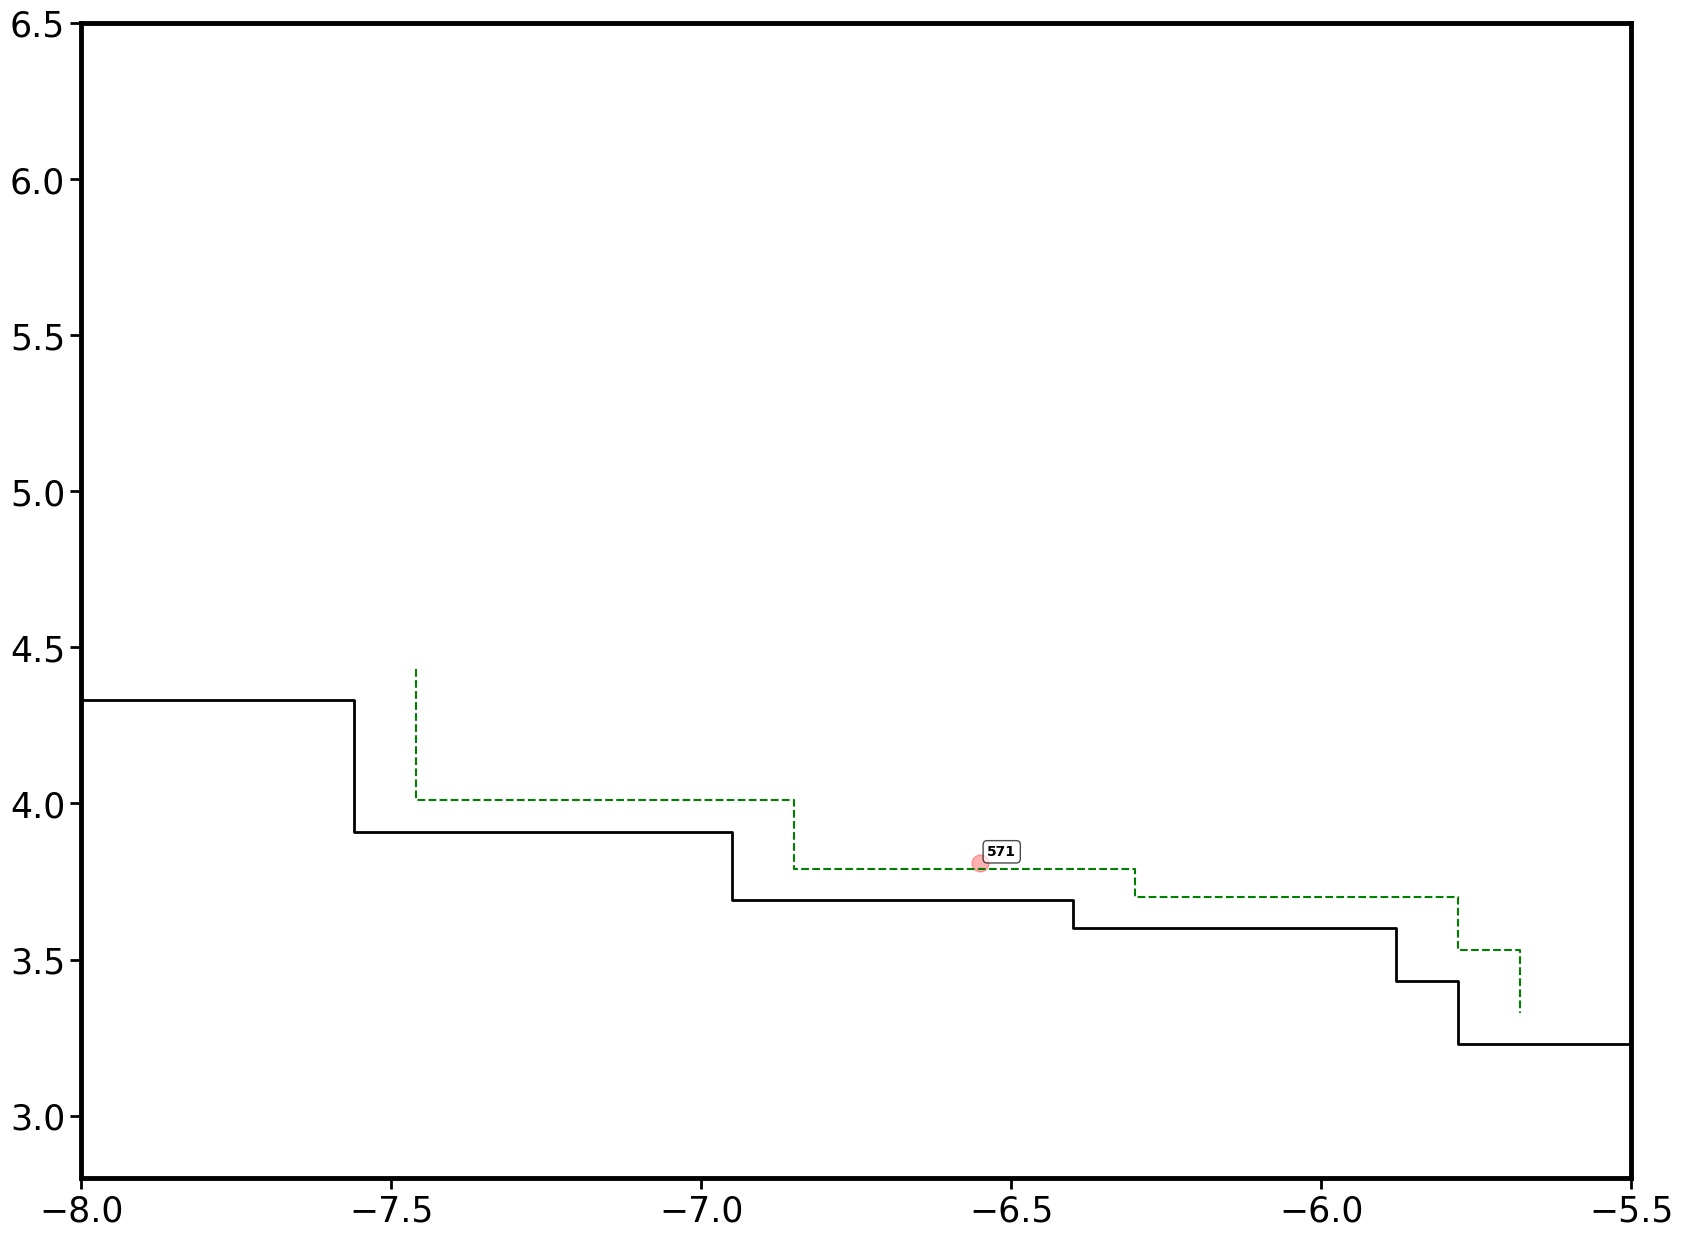

In [8]:
pd.options.display.width=80
r_c = df[ (df['class_2']== 0 )&( df['Re'] > 3.79) & (df['Re'] < 3.92) & ( df['Co'] > 6.3) & ( df['Co'] < 6.6)]
plt.figure(figsize=(20,15))
ax = plt.gca()  # 获取当前轴对象
ax.set_xlim(-8.0, -5.5)
ax.set_ylim(2.8, 6.5)
ax.spines['bottom'].set_linewidth(3.5)
ax.spines['left'].set_linewidth(3.5)
ax.spines['top'].set_linewidth(3.5)
ax.spines['right'].set_linewidth(3.5)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)
plt.scatter(-r_c.iloc[:,[8]], r_c.iloc[:,[9]] , s=150, marker='o', c='r',alpha=0.3)
plt.plot(pareto[:,0],pareto[:,1],c='k',linewidth=2,label='pareto')
shifted_y = pareto[5:15, 1] + 0.1
# 绘制y+0.1的新前沿
plt.plot(pareto[5:15, 0]+0.1, shifted_y, c='g', linestyle='--', linewidth=1.5, label='x+0.1')
# 标注序号
for i, idx in enumerate(r_c.index):
    plt.annotate(str(idx), 
                 xy=(-r_c.iloc[i, 8], r_c.iloc[i, 9]),
                 xytext=(5, 5),  # 文本偏移量
                 textcoords='offset points',
                 fontsize=10,
                 color='black',
                 fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.7))
print(r_c.index)
print(r_c.iloc[:,[8,9]])


In [9]:
# 标注序号
# for i, idx in enumerate(error_indices):
#     plt.annotate(str(idx), 
#                 xy=(-x_error.iloc[i, 0], y_error.iloc[i, 0]),
#                 xytext=(-x_error.iloc[i, 0], y_error.iloc[i, 0] + 0.15),
#                 fontsize=9,
#                 ha='center',
#                 va='bottom',
#                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7),  # 添加背景框
#                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2'))

# # 标注序号
# for i, idx in enumerate(error_indices1):
#     plt.annotate(str(idx), 
#                 xy=(-x_error1.iloc[i, 0], y_error1.iloc[i, 0]),
#                 xytext=(-x_error1.iloc[i, 0], y_error1.iloc[i, 0] + 0.15),
#                 fontsize=9,
#                 ha='center',
#                 va='bottom',
#                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7),  # 添加背景框
#                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2'))


# 在一块的一起标注
# annotations = {}
# threshold = 0.15  # 设置距离阈值，用于判断点是否接近

# for i, idx in enumerate(error_indices):
#     x, y = -x_error.iloc[i, 0], y_error.iloc[i, 0]
#     # 检查是否有接近的已存在的标注点
#     found_close = False
#     for key in annotations:
#         x_exist, y_exist = key
#         if abs(x - x_exist) < threshold and abs(y - y_exist) < threshold:
#             # 如果找到接近的点，将当前编号添加到已有标注中
#             annotations[key].append(str(idx))
#             found_close = True
#             break
#     # 如果没有找到接近的点，创建新的标注
#     if not found_close:
#         annotations[(x, y)] = [str(idx)]
# # 绘制标注
# for (x, y), indices in annotations.items():
#     label = '/'.join(indices)  # 用斜线连接多个编号
#     plt.annotate(label,
#                 xy=(x, y),
#                 xytext=(x-0.1, y + 0.35),
#                 fontsize=9,
#                 ha='center',
#                 va='bottom',
#                 bbox=dict(boxstyle='round,pad=0', facecolor='white', alpha=0.7),
#                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1'))
# # 测试集就近标注
# annotations1 = {}  
# for i, idx in enumerate(error_indices1):
#     x1, y1 = -x_error1.iloc[i, 0], y_error1.iloc[i, 0]
#     # 检查是否有接近的已存在的标注点
#     found_close = False
#     for key in annotations1:
#         x_exist, y_exist = key
#         if abs(x - x_exist) < threshold and abs(y - y_exist) < threshold:
#             # 如果找到接近的点，将当前编号添加到已有标注中
#             annotations1[key].append(str(idx))
#             found_close = True
#             break
#     # 如果没有找到接近的点，创建新的标注
#     if not found_close:
#         annotations1[(x, y)] = [str(idx)]
# # 绘制标注
# for (x, y), indices in annotations1.items():
#     label = '/'.join(indices)  # 用斜线连接多个编号
#     plt.annotate(label,
#                 xy=(x, y),
#                 xytext=(x-0.1, y + 0.35),
#                 fontsize=9,
#                 ha='center',
#                 va='bottom',
#                 bbox=dict(boxstyle='round,pad=0', facecolor='white', alpha=0.7),
#                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1'))

In [10]:
leaf_node = clf.apply(X_train) 
leaf_samples_original = {}
for train_idx, leaf_id in enumerate(leaf_ids):
    original_idx = idx_train[train_idx]  # 获取对应的原始索引
    if leaf_id not in leaf_samples_original:
        leaf_samples_original[leaf_id] = [] 
    leaf_samples_original[leaf_id].append(original_idx)
# 打印结果
print(f"总叶子节点数: {len(leaf_samples_original)}")

is_err = y_train_pred != y_train
err_node_df = pd.DataFrame({"leaf_node":leaf_node,"num":np.ones(len(leaf_node)).astype(int),"is_err":is_err})
err_node_df = err_node_df.groupby(["leaf_node"]).sum().reset_index(drop=False)
err_node_df["err_rate"] = err_node_df["is_err"]/err_node_df["num"]
err_node_df  = err_node_df[err_node_df['err_rate']>0].reset_index(drop=True)
err_node_df = err_node_df.sort_values(by='err_rate', ascending=False)

print("\n----错误样本在叶子节点的分布--------:")
print(err_node_df)

总叶子节点数: 6

----错误样本在叶子节点的分布--------:
   leaf_node  num  is_err  err_rate
3         10   23       5  0.217391
0          3    5       1  0.200000
2          9  124      15  0.120968
1          7   32       3  0.093750


In [11]:

# 创建字典存储每个叶子节点的样本索引
leaf_samples = {}
for i, leaf_id in enumerate(leaf_ids):
    if leaf_id not in leaf_samples:
        leaf_samples[leaf_id] = []
    leaf_samples[leaf_id].append(i)

print("=" * 80)
print("包含类别1的叶子节点详细信息")
print("=" * 80)

# 统计包含类别1的叶子节点
nodes_with_class1 = 0

for leaf_id, sample_indices in leaf_samples.items():
    # 获取该叶子节点中的实际标签和预测标签
    actual_labels = y_train[sample_indices]
    predicted_labels = y_train_pred[sample_indices] 
    # 检查是否包含类别1（实际或预测）
    has_actual_class1 = np.any(actual_labels == 1)
    has_predicted_class1 = np.any(predicted_labels == 1)  
    if has_actual_class1 or has_predicted_class1:
        nodes_with_class1 += 1
        print(f"叶子节点 {leaf_id}:")
        print(f"- 总样本数: {len(sample_indices)}")
        # 实际标签分布
        actual_counts = np.bincount(actual_labels, minlength=2)
        print(f"- 实际标签分布: 类别0={actual_counts[0]}, 类别1={actual_counts[1]}")     
        # 预测标签分布
        predicted_counts = np.bincount(predicted_labels, minlength=2)
        print(f"- 预测标签分布: 类别0={predicted_counts[0]}, 类别1={predicted_counts[1]}")
        # 找出类别1的样本（实际和预测）
        actual_class1_mask = actual_labels == 1
        predicted_class1_mask = predicted_labels == 1
        
        if has_actual_class1:
            actual_class1_indices = np.array(sample_indices)[actual_class1_mask]
            actual_class1_original_indices = idx_train[actual_class1_indices]
            print(f"- 实际类别1样本:")
            print(f"  实际1类数据索引: {actual_class1_original_indices}")
            # 显示这些样本的特征值
            
        if has_predicted_class1:
            predicted_class1_indices = np.array(sample_indices)[predicted_class1_mask]
            predicted_class1_original_indices = idx_train[predicted_class1_indices]
            print(f"- 预测类别1样本:")
            print(f"  预测1类数据索引: {predicted_class1_original_indices}")
            #打印预测1类的索引信息

        # 计算该节点的准确率
        correct_predictions = np.sum(actual_labels == predicted_labels)
        accuracy = correct_predictions / len(sample_indices)
        print(f"- 节点准确率: {accuracy:.3f} ({correct_predictions}/{len(sample_indices)})")
        
        print("-" * 80)

print(f"\n总结:")
print(f"包含类别1的叶子节点数量: {nodes_with_class1}")
print(f"总叶子节点数量: {len(leaf_samples)}")

# 额外：显示测试集中类别1的预测情况
print("\n" + "=" * 80)
print("测试集中类别1的预测情况")
print("=" * 80)

test_class1_mask = y_test == 1
test_class1_indices = np.where(test_class1_mask)[0]
test_class1_original_indices = idx_test[test_class1_indices]


包含类别1的叶子节点详细信息
叶子节点 9:
- 总样本数: 124
- 实际标签分布: 类别0=15, 类别1=109
- 预测标签分布: 类别0=0, 类别1=124
- 实际类别1样本:
  实际1类数据索引: [542 397 347  25 560 564 594 191  11 591  28 538 465 604 541 592 617 361
 546 555 192 563  16 370 526 570 587 434 330 607 106 519 378 471 568 320
 494 569 612 616 354 348 575 287 352 603 414 388  56 383 343 599 513 298
 566 349 562 377 184 435 620 500 581 248 619  78 531 615 520 512 501 371
 600 588 559 590 586 369 364  48 326 548 443 133 578 376 381  27 359 510
 464 463 540 340 346 611 554 472 574 382 565 375 360 355 534 331  15 318
 384]
- 预测类别1样本:
  预测1类数据索引: [542 397 347  25 560 564 211 594 618 191  11 591  28 538 465 604 515 541
 592 617 361 546 555 192 563  16 370 526 570 587 511 434 330 607 106 519
 378 471 568 220 320 533 494 514 569 612 589 616 354 571 348 575 558 287
 352 603 414 388  56 383 343 599 513 298 566 349 562 377 184 435 620 500
 581 248 619 525  78 531 615 520 512 501 371 600 588 559 590 586 369 364
  48 326 548 443 133 578 376 381  27 317 359 510 464 463 54

In [12]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # 读取数据
# df = pd.read_csv("class_2.csv")
# df['original_index'] = df.index  # 保存原始索引以便追踪
# X_ = -df.iloc[:, 8].values  # 提取为numpy数组
# y_ = df.iloc[:, 9].values  # 提取为numpy数组
# class_info = df.iloc[:, -2].values

# # 读取帕累托前沿数据
# pareto = np.loadtxt('pareto', delimiter=',')
# pareto_x = pareto[:, 0]
# pareto_y = pareto[:, 1]

# # 函数：判断点是否被帕累托前沿支配
# def is_dominated(x, y, pareto_x, pareto_y):
#     """
#     判断点(x, y)是否被帕累托前沿上的任何点支配
#     支配的定义：点A支配点B，如果点A在所有维度上不比B差，且至少在一个维度上比B好
#     """
#     for px, py in zip(pareto_x, pareto_y):
#         # 如果前沿上有点在两个维度上都不劣于该点，且至少一个维度上优于该点
#         # 假设较小的值更好
#         if px <= x and py <= y:
#             return True
#     return False

# # 找出所有被帕累托前沿支配的点的索引
# dominated_indices = []
# non_dominated_indices = []

# for i in range(len(X_)):
#     if is_dominated(X_[i], y_[i], pareto_x, pareto_y):
#         dominated_indices.append(df['original_index'].iloc[i])
#     else:
#         non_dominated_indices.append(df['original_index'].iloc[i])

# print(f"被帕累托前沿支配的点的索引: {non_dominated_indices}")


# # 可视化
# plt.figure(figsize=(10, 8))
# plt.scatter(X_, y_, c='blue', alpha=0.5, label='所有点')
# plt.scatter(X_[dominated_indices], y_[dominated_indices], c='red', marker='x', label='被支配的点')
# plt.plot(pareto_x, pareto_y, 'g-', marker='o', label='帕累托前沿')
# plt.xlabel('X轴')
# plt.ylabel('Y轴')
# plt.title('帕累托前沿分析')
# plt.legend()
# plt.grid(True)
# plt.show()

# # 如果你想获取更多关于这些点的信息
# non_dominated_points = df.iloc[non_dominated_indices]
# print("\n被支配点的详细信息:")
# print(non_dominated_points)
# print(non_dominated_points.s)
